In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
import re

# Set the consistent theme style from metrics.ipynb
sns.set_theme(style="whitegrid", 
              palette="dark", 
              font="Quicksand Medium", 
              rc={
                "grid.linewidth": 1,    # Thinner gridlines
                "xtick.labelsize": 14,       # X-axis tick labels
                "ytick.labelsize": 14,       # Y-axis tick labels
                "axes.titlesize": 14,     # Larger title font
                "axes.labelsize": 14,     # Adjust label font size
                "legend.frameon": True,   # Add a frame to the legend
                  }, 
              context="talk")

# Define consistent colors
color_primary = "#4f4f4f"  # Dark grey
color_secondary = "#a0a0a0"  # Light grey
color_accent = "#2E86AB"  # Blue
color_highlight = "#A23B72"  # Purple

# Hyperparameter Sweep Results Analysis

Analyzing the results of all transformer model runs for both Geolife and Mobis datasets.

In [10]:
from pathlib import Path
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Base directory for experiments
BASE_DIR = Path("/data/A-SpeedTransformer/models/transformer/experiments")

# Regular expression for extracting metrics from logs
ACC_RE = re.compile(
    r"Test\s+Loss:\s*([0-9]*\.?[0-9]+(?:[eE][+-]?\d+)?)\s*,\s*"
    r"Test\s+Accuracy:\s*([0-9]*\.?[0-9]+(?:[eE][+-]?\d+)?)"
)

def parse_hyperparams(run_dir: Path):
    """Extract hyperparameters from run directory name."""
    name = run_dir.name
    params = {}
    
    # Extract learning rate
    lr_match = re.search(r"lr([\d.e-]+)", name)
    if lr_match:
        params['learning_rate'] = float(lr_match.group(1))
    
    # Extract batch size
    bs_match = re.search(r"bs(\d+)", name)
    if bs_match:
        params['batch_size'] = int(bs_match.group(1))
    
    # Extract number of heads
    h_match = re.search(r"h(\d+)", name)
    if h_match:
        params['n_heads'] = int(h_match.group(1))
    
    # Extract d_model
    d_match = re.search(r"d(\d+)", name)
    if d_match:
        params['d_model'] = int(d_match.group(1))
    
    # Extract kv_heads
    kv_match = re.search(r"kv(\d+)", name)
    if kv_match:
        params['kv_heads'] = int(kv_match.group(1))
    
    # Extract dropout
    do_match = re.search(r"do([\d.]+)", name)
    if do_match:
        params['dropout'] = float(do_match.group(1))
    
    return params

def parse_last_acc(log_path: Path):
    """Return (loss, acc) from the LAST matching line in the log."""
    last = None
    try:
        with log_path.open("r", errors="ignore") as f:
            for line in f:
                m = ACC_RE.search(line)
                if m:
                    loss = float(m.group(1))
                    acc = float(m.group(2))
                    last = (loss, acc)
    except FileNotFoundError:
        return None
    return last

# Collect results for both datasets
results = []

for dataset_dir in BASE_DIR.glob("*_transformer_sweeps"):
    dataset = dataset_dir.name.replace("_transformer_sweeps", "")
    
    for run_dir in dataset_dir.glob("*"):
        log_path = run_dir / "train.log"
        if not log_path.exists():
            continue
            
        parsed = parse_last_acc(log_path)
        if parsed is None:
            continue
            
        loss, acc = parsed
        params = parse_hyperparams(run_dir)
        
        results.append({
            "dataset": dataset,
            "run_name": run_dir.name,
            "test_loss": loss,
            "test_acc": acc * 100,  # Convert to percentage
            **params
        })

# Convert to DataFrame and sort by accuracy
df_results = pd.DataFrame(results)

# Display results for each dataset, sorted by accuracy
for dataset in df_results['dataset'].unique():
    print(f"\n=== {dataset.upper()} Dataset Results ===")
    df_subset = df_results[df_results['dataset'] == dataset].sort_values('test_acc', ascending=False)
    
    # Show results with key hyperparameters
    display(df_subset[['test_acc', 'test_loss', 'learning_rate', 'batch_size', 
                      'n_heads', 'd_model', 'kv_heads', 'dropout', 'run_name']])


=== MOBIS Dataset Results ===


,test_acc,test_loss,learning_rate,batch_size,n_heads,d_model,kv_heads,dropout,run_name
7,94.22,0.1627,0.0001,512,8,128,4,0.1,mobis_lr1e-4_bs512_h8_d128_kv4_do0.1
6,94.20,0.1742,0.0002,512,8,128,2,0.1,mobis_lr2e-4_bs512_h8_d128_kv2_do0.1
1,94.09,0.1706,0.0003,512,8,128,4,0.1,mobis_lr3e-4_bs512_h8_d128_kv4_do0.1
5,93.71,0.1782,0.0002,512,12,192,6,0.1,mobis_lr2e-4_bs512_h12_d192_kv6_do0.1
2,93.69,0.1809,0.0002,512,8,128,4,0.1,mobis_lr2e-4_bs512_h8_d128_kv4_do0.1
4,93.69,0.1805,0.0002,1024,8,128,4,0.1,mobis_lr2e-4_bs1024_h8_d128_kv4_do0.1
0,93.54,0.1834,0.0002,512,8,256,4,0.1,mobis_lr2e-4_bs512_h8_d256_kv4_do0.1
3,93.54,0.1832,0.0002,512,8,128,4,0.2,mobis_lr2e-4_bs512_h8_d128_kv4_do0.2



=== GEOLIFE Dataset Results ===


,test_acc,test_loss,learning_rate,batch_size,n_heads,d_model,kv_heads,dropout,run_name
12,95.97,0.1525,0.0002,512,8,128,4,0.1,lr2e-4_bs512_h8_d128_kv4_do0.1
13,95.36,0.1646,0.0002,512,8,128,2,0.1,lr2e-4_bs512_h8_d128_kv2_do0.1
15,94.72,0.1830,0.0002,512,12,192,6,0.1,lr2e-4_bs512_h12_d192_kv6_do0.1
10,94.69,0.1744,0.0002,512,8,256,4,0.1,lr2e-4_bs512_h8_d256_kv4_do0.1
11,94.68,0.1813,0.0003,512,8,128,4,0.1,lr3e-4_bs512_h8_d128_kv4_do0.1
8,94.44,0.2007,0.0001,512,8,128,4,0.1,lr1e-4_bs512_h8_d128_kv4_do0.1
9,92.72,0.2421,0.0002,1024,8,128,4,0.1,lr2e-4_bs1024_h8_d128_kv4_do0.1
14,92.70,0.2624,0.0002,512,8,128,4,0.2,lr2e-4_bs512_h8_d128_kv4_do0.2


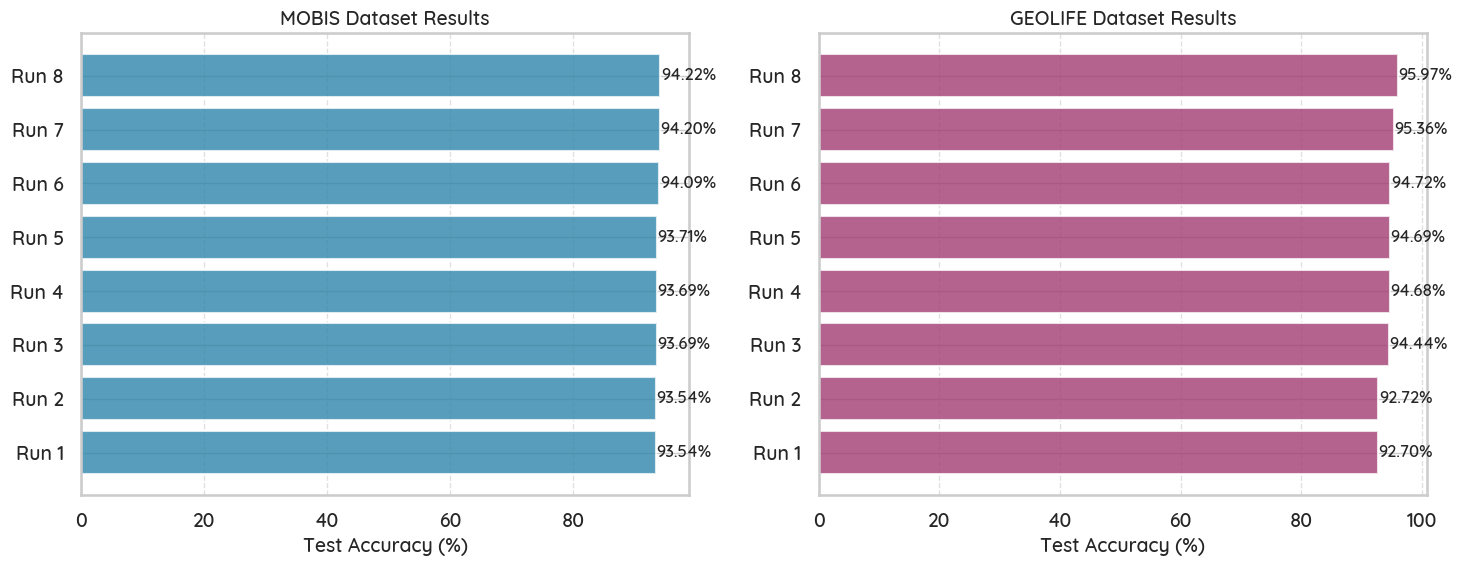


Best Configurations:

MOBIS:
Test Accuracy: 94.22%
Test Loss: 0.1627
Hyperparameters:
- Learning Rate: 0.0001
- Batch Size: 512
- Number of Heads: 8
- d_model: 128
- KV Heads: 4
- Dropout: 0.1
Run Name: mobis_lr1e-4_bs512_h8_d128_kv4_do0.1

GEOLIFE:
Test Accuracy: 95.97%
Test Loss: 0.1525
Hyperparameters:
- Learning Rate: 0.0002
- Batch Size: 512
- Number of Heads: 8
- d_model: 128
- KV Heads: 4
- Dropout: 0.1
Run Name: lr2e-4_bs512_h8_d128_kv4_do0.1


In [11]:
# Create visualization of results with consistent theme
plt.figure(figsize=(15, 6))

# Plot side by side bar plots for both datasets
for idx, dataset in enumerate(df_results['dataset'].unique()):
    plt.subplot(1, 2, idx+1)
    
    df_subset = df_results[df_results['dataset'] == dataset].sort_values('test_acc', ascending=True)
    
    # Create bar plot with consistent colors
    bars = plt.barh(range(len(df_subset)), df_subset['test_acc'], 
                   color=color_accent if idx == 0 else color_highlight, alpha=0.8)
    
    # Add value labels on the bars
    for i, v in enumerate(df_subset['test_acc']):
        plt.text(v + 0.1, i, f'{v:.2f}%', va='center', fontsize=12, fontweight='bold')
    
    # Customize the plot
    plt.title(f'{dataset.upper()} Dataset Results')
    plt.xlabel('Test Accuracy (%)')
    plt.yticks(range(len(df_subset)), [f'Run {i+1}' for i in range(len(df_subset))])
    plt.grid(True, linestyle='--', alpha=0.6, axis='x')

plt.tight_layout()
plt.show()

# Print best configuration for each dataset
print("\nBest Configurations:")
for dataset in df_results['dataset'].unique():
    best_run = df_results[df_results['dataset'] == dataset].sort_values('test_acc', ascending=False).iloc[0]
    print(f"\n{dataset.upper()}:")
    print(f"Test Accuracy: {best_run['test_acc']:.2f}%")
    print(f"Test Loss: {best_run['test_loss']:.4f}")
    print("Hyperparameters:")
    print(f"- Learning Rate: {best_run['learning_rate']}")
    print(f"- Batch Size: {best_run['batch_size']}")
    print(f"- Number of Heads: {best_run['n_heads']}")
    print(f"- d_model: {best_run['d_model']}")
    print(f"- KV Heads: {best_run['kv_heads']}")
    print(f"- Dropout: {best_run['dropout']}")
    print(f"Run Name: {best_run['run_name']}")

# Window Size Sweep Analysis

Analyzing the results of different window sizes for the Geolife dataset using the best hyperparameter configuration.

In [12]:
from pathlib import Path
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Base directory for window size experiments
BASE_DIR = Path("/data/A-SpeedTransformer/models/transformer/experiments/geolife_window_sweeps")

# Regular expression for extracting metrics from logs
ACC_RE = re.compile(
    r"Test\s+Loss:\s*([0-9]*\.?[0-9]+(?:[eE][+-]?\d+)?)\s*,\s*"
    r"Test\s+Accuracy:\s*([0-9]*\.?[0-9]+(?:[eE][+-]?\d+)?)"
)

def parse_window_size(run_dir: Path):
    """Extract window size from run directory name."""
    name = run_dir.name
    ws_match = re.search(r"ws(\d+)", name)
    if ws_match:
        return int(ws_match.group(1))
    return None

def parse_last_acc(log_path: Path):
    """Return (loss, acc) from the LAST matching line in the log."""
    last = None
    try:
        with log_path.open("r", errors="ignore") as f:
            for line in f:
                m = ACC_RE.search(line)
                if m:
                    loss = float(m.group(1))
                    acc = float(m.group(2))
                    last = (loss, acc)
    except FileNotFoundError:
        return None
    return last

# Collect results
results = []

for run_dir in BASE_DIR.glob("*"):
    log_path = run_dir / "train.log"
    if not log_path.exists():
        continue
        
    parsed = parse_last_acc(log_path)
    if parsed is None:
        continue
        
    loss, acc = parsed
    window_size = parse_window_size(run_dir)
    
    if window_size is not None:
        results.append({
            "window_size": window_size,
            "test_loss": loss,
            "test_acc": acc * 100,  # Convert to percentage
            "run_name": run_dir.name
        })

# Convert to DataFrame and sort by window size
df_results = pd.DataFrame(results).sort_values('window_size')

# Display results
print("\n=== Window Size Sweep Results ===")
display(df_results[['window_size', 'test_acc', 'test_loss', 'run_name']])


=== Window Size Sweep Results ===


,window_size,test_acc,test_loss,run_name
6,20,77.58,0.5778,geolife_ws20_lr2e-4_bs512_h8_d128_kv4_do0.1
1,50,84.86,0.4043,geolife_ws50_lr2e-4_bs512_h8_d128_kv4_do0.1
4,100,92.07,0.2600,geolife_ws100_lr2e-4_bs512_h8_d128_kv4_do0.1
2,200,95.97,0.1525,geolife_ws200_lr2e-4_bs512_h8_d128_kv4_do0.1
3,300,95.04,0.1753,geolife_ws300_lr2e-4_bs512_h8_d128_kv4_do0.1
0,400,94.53,0.1703,geolife_ws400_lr2e-4_bs256_h8_d128_kv4_do0.1
5,500,95.03,0.1800,geolife_ws500_lr2e-4_bs256_h8_d128_kv4_do0.1


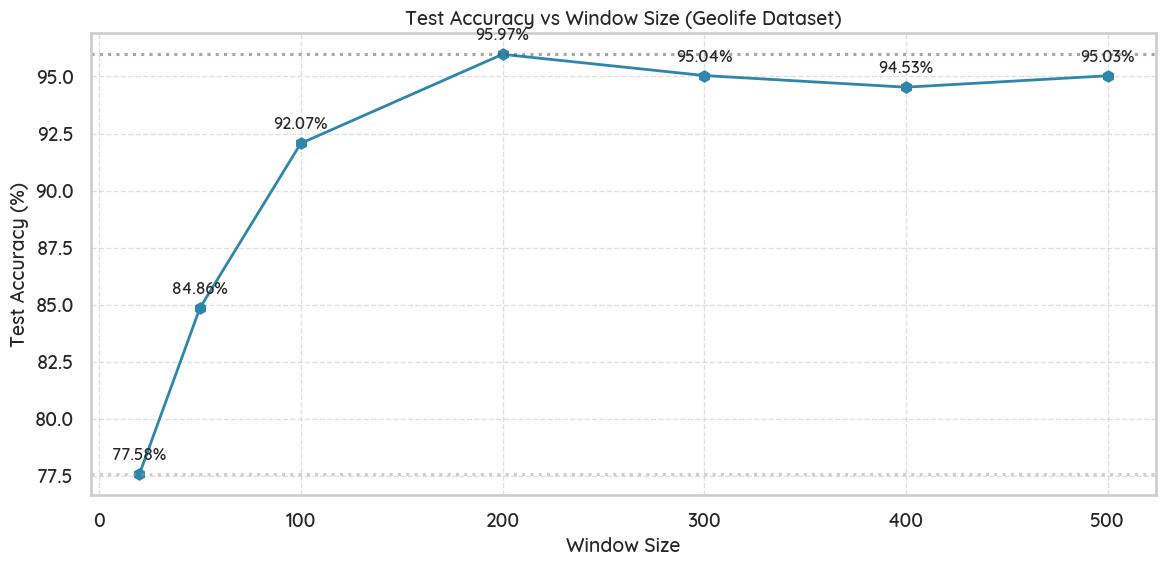


Best Window Size Configuration:
Window Size: 200
Test Accuracy: 95.97%
Test Loss: 0.1525
Run Name: geolife_ws200_lr2e-4_bs512_h8_d128_kv4_do0.1

Relative to baseline (window_size=200, 95.97%):
Window Size 20: -18.39% (77.58%)
Window Size 50: -11.11% (84.86%)
Window Size 100: -3.90% (92.07%)
Window Size 200: +0.00% (95.97%)
Window Size 300: -0.93% (95.04%)
Window Size 400: -1.44% (94.53%)
Window Size 500: -0.94% (95.03%)


In [13]:
# Create visualization with consistent theme
plt.figure(figsize=(12, 6))

# Create line plot with markers
plt.plot(df_results['window_size'], df_results['test_acc'], 
         marker='h', linestyle='-', linewidth=2, markersize=8, color=color_accent)

# Add value labels
for x, y in zip(df_results['window_size'], df_results['test_acc']):
    plt.annotate(f'{y:.2f}%', 
                (x, y), 
                textcoords="offset points", 
                xytext=(0, 10),
                ha='center',
                fontsize=12,
                fontweight='bold')

# Customize the plot
plt.title('Test Accuracy vs Window Size (Geolife Dataset)')
plt.xlabel('Window Size')
plt.ylabel('Test Accuracy (%)')
plt.grid(True, linestyle='--', alpha=0.6)

# Add horizontal lines at min/max accuracy for reference
plt.axhline(y=df_results['test_acc'].max(), color=color_primary, linestyle=':', alpha=0.5)
plt.axhline(y=df_results['test_acc'].min(), color=color_secondary, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

# Print best window size configuration
best_config = df_results.loc[df_results['test_acc'].idxmax()]
print("\nBest Window Size Configuration:")
print(f"Window Size: {best_config['window_size']}")
print(f"Test Accuracy: {best_config['test_acc']:.2f}%")
print(f"Test Loss: {best_config['test_loss']:.4f}")
print(f"Run Name: {best_config['run_name']}")

# Print relative performance impact
baseline_acc = df_results.loc[df_results['window_size'] == 200, 'test_acc'].iloc[0]
print(f"\nRelative to baseline (window_size=200, {baseline_acc:.2f}%):")
for _, row in df_results.iterrows():
    diff = row['test_acc'] - baseline_acc
    print(f"Window Size {row['window_size']}: {diff:+.2f}% ({row['test_acc']:.2f}%)")

# Finetune Sweep Analysis

Analyzing the results of finetuning experiments to find the best configuration.

In [14]:
from pathlib import Path
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Base directory for finetune experiments
BASE_DIR = Path("/data/A-SpeedTransformer/models/transformer/experiments/finetune_sweeps")

# Regular expression for extracting metrics from logs
ACC_RE = re.compile(
    r"Test\s+Loss:\s*([0-9]*\.?[0-9]+(?:[eE][+-]?\d+)?)\s*,\s*"
    r"Test\s+Accuracy:\s*([0-9]*\.?[0-9]+(?:[eE][+-]?\d+)?)"
)

def parse_finetune_params(run_dir: Path):
    """Extract parameters from finetune run directory name."""
    name = run_dir.name
    params = {}
    
    # Extract learning rate
    lr_match = re.search(r"lr([\d.e-]+)", name)
    if lr_match:
        params['learning_rate'] = float(lr_match.group(1))
    
    # Extract warmup steps
    warmup_match = re.search(r"warmup(\d+)", name)
    if warmup_match:
        params['warmup_steps'] = int(warmup_match.group(1))
    
    # Extract freeze strategy
    if "freeze_attention" in name:
        params['freeze_strategy'] = "attention"
    elif "freeze_embeddings" in name:
        params['freeze_strategy'] = "embeddings"
    elif "freeze_feedforward" in name:
        params['freeze_strategy'] = "feedforward"
    elif "freeze_first_half" in name:
        params['freeze_strategy'] = "first_half"
    elif "full" in name:
        params['freeze_strategy'] = "none"
    elif "grad_unfreeze" in name:
        params['freeze_strategy'] = "gradual_unfreeze"
    elif "reinit_last" in name:
        params['freeze_strategy'] = "reinit_last"
    
    return params

def parse_last_acc(log_path: Path):
    """Return (loss, acc) from the LAST matching line in the log."""
    last = None
    try:
        with log_path.open("r", errors="ignore") as f:
            for line in f:
                m = ACC_RE.search(line)
                if m:
                    loss = float(m.group(1))
                    acc = float(m.group(2))
                    last = (loss, acc)
    except FileNotFoundError:
        return None
    return last

# Collect results
results = []

if BASE_DIR.exists():
    for run_dir in BASE_DIR.glob("*"):
        log_path = run_dir / "finetune.log"  # Changed from train.log to finetune.log
        if not log_path.exists():
            continue
            
        parsed = parse_last_acc(log_path)
        if parsed is None:
            continue
            
        loss, acc = parsed
        params = parse_finetune_params(run_dir)
        
        results.append({
            "test_loss": loss,
            "test_acc": acc * 100,  # Convert to percentage
            "run_name": run_dir.name,
            **params
        })

# Convert to DataFrame and sort by accuracy
df_finetune = pd.DataFrame(results)
if not df_finetune.empty:
    df_finetune = df_finetune.sort_values('test_acc', ascending=False)

    # Display results
    print("\n=== Finetune Sweep Results ===")
    display(df_finetune[['test_acc', 'test_loss', 'learning_rate', 
                        'warmup_steps', 'freeze_strategy', 'run_name']])
    
    # Display summary statistics by strategy
    print("\n=== Performance by Freeze Strategy ===")
    strategy_stats = df_finetune.groupby('freeze_strategy')['test_acc'].agg(['mean', 'std', 'count']).round(2)
    strategy_stats = strategy_stats.sort_values('mean', ascending=False)
    display(strategy_stats)
    
    # Display summary statistics by learning rate
    print("\n=== Performance by Learning Rate ===")
    lr_stats = df_finetune.groupby('learning_rate')['test_acc'].agg(['mean', 'std', 'count']).round(2)
    lr_stats = lr_stats.sort_values('mean', ascending=False)
    display(lr_stats)
else:
    print("No finetune sweep results found in:", BASE_DIR)


=== Finetune Sweep Results ===


,test_acc,test_loss,learning_rate,warmup_steps,freeze_strategy,run_name
31,86.38,0.6456,0.00020,0,attention,lr2e-4_warmup0_freeze_attention
6,86.30,0.5484,0.00020,0,reinit_last,lr2e-4_warmup0_reinit_last
43,85.70,0.5393,0.00010,0,reinit_last,lr1e-4_warmup0_reinit_last
44,85.07,0.5397,0.00005,0,reinit_last,lr5e-5_warmup0_reinit_last
23,85.01,0.7297,0.00020,0,none,lr2e-4_warmup0_full
...,...,...,...,...,...,...
13,63.67,2.4539,0.00005,0,gradual_unfreeze,lr5e-5_warmup0_grad_unfreeze
51,63.64,2.4589,0.00005,500,gradual_unfreeze,lr5e-5_warmup500_grad_unfreeze
40,63.58,2.4631,0.00010,0,gradual_unfreeze,lr1e-4_warmup0_grad_unfreeze
11,63.53,2.3803,0.00005,0,embeddings,lr5e-5_warmup0_freeze_embeddings



=== Performance by Freeze Strategy ===


,mean,std,count
freeze_strategy,,,
reinit_last,72.90,9.60,9
embeddings,68.44,9.17,9
none,68.43,9.14,9
feedforward,67.10,6.96,9
attention,66.38,7.50,9
first_half,65.89,5.96,9
gradual_unfreeze,63.57,0.39,9



=== Performance by Learning Rate ===


,mean,std,count
learning_rate,,,
0.00020,69.96,9.58,21
0.00010,67.55,7.53,21
0.00005,65.08,4.66,21


/tmp/ipykernel_1084685/1591095389.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_finetune, x='freeze_strategy', y='test_acc', palette=[color_accent])
/tmp/ipykernel_1084685/1591095389.py:6: UserWarning: 
The palette list has fewer values (1) than needed (7) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(data=df_finetune, x='freeze_strategy', y='test_acc', palette=[color_accent])
/tmp/ipykernel_1084685/1591095389.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_finetune, x='learning_rate', y='test_acc', palette=[color_highlight])
/tmp/ipykernel_1084685/1591095389.py:15: UserWarning: 
The palette list has fewer values (1) than needed (3) and

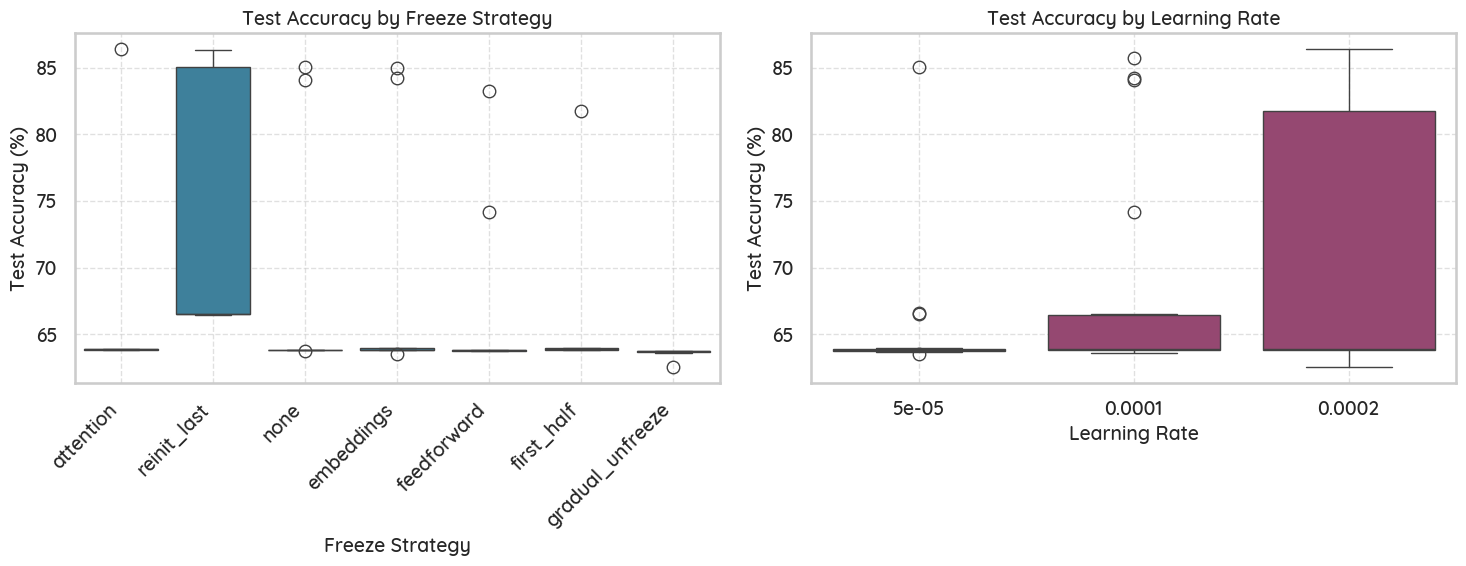

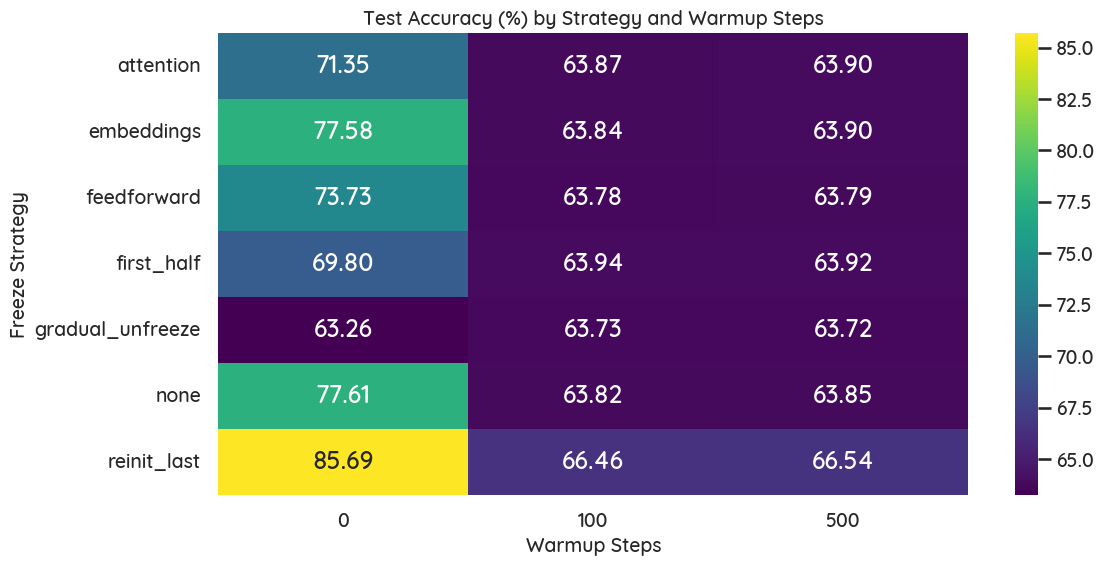


Best Finetune Configuration:
Test Accuracy: 86.38%
Test Loss: 0.6456

Hyperparameters:
- Learning Rate: 0.0002
- Warmup Steps: 0
- Freeze Strategy: attention

Run Name: lr2e-4_warmup0_freeze_attention

Top 3 Freeze Strategies:
reinit_last:
  Mean Accuracy: 72.90% ± 9.60%
embeddings:
  Mean Accuracy: 68.44% ± 9.17%
none:
  Mean Accuracy: 68.43% ± 9.14%


In [15]:
# Create visualizations with consistent theme
if not df_finetune.empty:
    # 1. Box plot by freeze strategy
    plt.figure(figsize=(15, 6))
    plt.subplot(1, 2, 1)
    sns.boxplot(data=df_finetune, x='freeze_strategy', y='test_acc', palette=[color_accent])
    plt.xticks(rotation=45, ha='right')
    plt.title('Test Accuracy by Freeze Strategy')
    plt.xlabel('Freeze Strategy')
    plt.ylabel('Test Accuracy (%)')
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # 2. Box plot by learning rate
    plt.subplot(1, 2, 2)
    sns.boxplot(data=df_finetune, x='learning_rate', y='test_acc', palette=[color_highlight])
    plt.title('Test Accuracy by Learning Rate')
    plt.xlabel('Learning Rate')
    plt.ylabel('Test Accuracy (%)')
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()
    
    # 3. Heatmap of warmup steps vs strategies
    plt.figure(figsize=(12, 6))
    pivot_table = df_finetune.pivot_table(
        values='test_acc', 
        index='freeze_strategy',
        columns='warmup_steps',
        aggfunc='mean'
    )
    
    sns.heatmap(pivot_table, annot=True, fmt='.2f', cmap='viridis')
    plt.title('Test Accuracy (%) by Strategy and Warmup Steps')
    plt.xlabel('Warmup Steps')
    plt.ylabel('Freeze Strategy')
    plt.tight_layout()
    plt.show()

    # Print best configuration
    best_config = df_finetune.iloc[0]
    print("\nBest Finetune Configuration:")
    print(f"Test Accuracy: {best_config['test_acc']:.2f}%")
    print(f"Test Loss: {best_config['test_loss']:.4f}")
    print("\nHyperparameters:")
    print(f"- Learning Rate: {best_config['learning_rate']}")
    print(f"- Warmup Steps: {best_config['warmup_steps']}")
    print(f"- Freeze Strategy: {best_config['freeze_strategy']}")
    print(f"\nRun Name: {best_config['run_name']}")
    
    # Print top 3 strategies
    print("\nTop 3 Freeze Strategies:")
    top_strategies = df_finetune.groupby('freeze_strategy')['test_acc'].agg(['mean', 'std']).round(2)
    top_strategies = top_strategies.sort_values('mean', ascending=False).head(3)
    for strategy, stats in top_strategies.iterrows():
        print(f"{strategy}:")
        print(f"  Mean Accuracy: {stats['mean']:.2f}% ± {stats['std']:.2f}%")

# Enhanced Transformer Sweeps Analysis

Analyzing the results from the advanced transformer architecture (transformer_) for both Geolife and MOBIS datasets.

In [16]:
from pathlib import Path
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Base directories for the enhanced transformer experiments
GEOLIFE_DIR = Path("/data/A-SpeedTransformer/models/transformer/experiments/geolife_transformer_sweeps")
MOBIS_DIR = Path("/data/A-SpeedTransformer/models/transformer/experiments/mobis_transformer_sweeps")

# Regular expression for extracting metrics from logs
ACC_RE = re.compile(
    r"Test\s+Loss:\s*([0-9]*\.?[0-9]+(?:[eE][+-]?\d+)?)\s*,\s*"
    r"Test\s+Accuracy:\s*([0-9]*\.?[0-9]+(?:[eE][+-]?\d+)?)"
)

def parse_hyperparams_enhanced(run_dir: Path):
    """Extract hyperparameters from enhanced transformer run directory name."""
    name = run_dir.name
    params = {}
    
    # Extract learning rate
    lr_match = re.search(r"lr([\d.e-]+)", name)
    if lr_match:
        params['learning_rate'] = float(lr_match.group(1))
    
    # Extract batch size
    bs_match = re.search(r"bs(\d+)", name)
    if bs_match:
        params['batch_size'] = int(bs_match.group(1))
    
    # Extract number of query heads
    h_match = re.search(r"h(\d+)", name)
    if h_match:
        params['n_heads'] = int(h_match.group(1))
    
    # Extract d_model
    d_match = re.search(r"d(\d+)", name)
    if d_match:
        params['d_model'] = int(d_match.group(1))
    
    # Extract kv_heads (key-value heads for GQA)
    kv_match = re.search(r"kv(\d+)", name)
    if kv_match:
        params['kv_heads'] = int(kv_match.group(1))
    
    # Extract dropout
    do_match = re.search(r"do([\d.]+)", name)
    if do_match:
        params['dropout'] = float(do_match.group(1))
    
    # Extract number of layers
    l_match = re.search(r"l(\d+)", name)
    if l_match:
        params['num_layers'] = int(l_match.group(1))
    
    return params

def parse_last_acc(log_path: Path):
    """Return (loss, acc) from the LAST matching line in the log."""
    last = None
    try:
        with log_path.open("r", errors="ignore") as f:
            for line in f:
                m = ACC_RE.search(line)
                if m:
                    loss = float(m.group(1))
                    acc = float(m.group(2))
                    last = (loss, acc)
    except FileNotFoundError:
        return None
    return last

# Collect results for both datasets
enhanced_results = []

for dataset_dir, dataset_name in [(GEOLIFE_DIR, "geolife"), (MOBIS_DIR, "mobis")]:
    if not dataset_dir.exists():
        print(f"Directory not found: {dataset_dir}")
        continue
        
    for run_dir in dataset_dir.glob("*"):
        if not run_dir.is_dir():
            continue
            
        log_path = run_dir / "train.log"
        if not log_path.exists():
            continue
            
        parsed = parse_last_acc(log_path)
        if parsed is None:
            continue
            
        loss, acc = parsed
        params = parse_hyperparams_enhanced(run_dir)
        
        enhanced_results.append({
            "dataset": dataset_name,
            "run_name": run_dir.name,
            "test_loss": loss,
            "test_acc": acc * 100,  # Convert to percentage
            **params
        })

# Convert to DataFrame
df_enhanced = pd.DataFrame(enhanced_results)

if not df_enhanced.empty:
    print(f"Found {len(df_enhanced)} enhanced transformer experiments")
    print(f"Datasets: {df_enhanced['dataset'].unique()}")
    
    # Check which columns are available
    available_cols = df_enhanced.columns.tolist()
    print(f"Available columns: {available_cols}")
    
    # Define the desired display columns and filter for available ones
    desired_cols = ['test_acc', 'test_loss', 'learning_rate', 'batch_size', 
                   'n_heads', 'kv_heads', 'd_model', 'num_layers', 'dropout', 'run_name']
    display_cols = [col for col in desired_cols if col in available_cols]
    
    # Display top results for each dataset
    for dataset in df_enhanced['dataset'].unique():
        print(f"\n=== {dataset.upper()} Enhanced Transformer Results ===")
        df_subset = df_enhanced[df_enhanced['dataset'] == dataset].sort_values('test_acc', ascending=False)
        
        # Show top 10 results with available hyperparameters
        display(df_subset.head(10)[display_cols])
else:
    print("No enhanced transformer results found in the specified directories")
    print(f"Checked directories:")
    print(f"- {GEOLIFE_DIR}")
    print(f"- {MOBIS_DIR}")

Found 16 enhanced transformer experiments
Datasets: ['geolife' 'mobis']
Available columns: ['dataset', 'run_name', 'test_loss', 'test_acc', 'learning_rate', 'batch_size', 'n_heads', 'd_model', 'kv_heads', 'dropout']

=== GEOLIFE Enhanced Transformer Results ===


,test_acc,test_loss,learning_rate,batch_size,n_heads,kv_heads,d_model,dropout,run_name
4,95.97,0.1525,0.0002,512,8,4,128,0.1,lr2e-4_bs512_h8_d128_kv4_do0.1
5,95.36,0.1646,0.0002,512,8,2,128,0.1,lr2e-4_bs512_h8_d128_kv2_do0.1
7,94.72,0.1830,0.0002,512,12,6,192,0.1,lr2e-4_bs512_h12_d192_kv6_do0.1
2,94.69,0.1744,0.0002,512,8,4,256,0.1,lr2e-4_bs512_h8_d256_kv4_do0.1
3,94.68,0.1813,0.0003,512,8,4,128,0.1,lr3e-4_bs512_h8_d128_kv4_do0.1
0,94.44,0.2007,0.0001,512,8,4,128,0.1,lr1e-4_bs512_h8_d128_kv4_do0.1
1,92.72,0.2421,0.0002,1024,8,4,128,0.1,lr2e-4_bs1024_h8_d128_kv4_do0.1
6,92.70,0.2624,0.0002,512,8,4,128,0.2,lr2e-4_bs512_h8_d128_kv4_do0.2



=== MOBIS Enhanced Transformer Results ===


,test_acc,test_loss,learning_rate,batch_size,n_heads,kv_heads,d_model,dropout,run_name
15,94.22,0.1627,0.0001,512,8,4,128,0.1,mobis_lr1e-4_bs512_h8_d128_kv4_do0.1
14,94.20,0.1742,0.0002,512,8,2,128,0.1,mobis_lr2e-4_bs512_h8_d128_kv2_do0.1
9,94.09,0.1706,0.0003,512,8,4,128,0.1,mobis_lr3e-4_bs512_h8_d128_kv4_do0.1
13,93.71,0.1782,0.0002,512,12,6,192,0.1,mobis_lr2e-4_bs512_h12_d192_kv6_do0.1
10,93.69,0.1809,0.0002,512,8,4,128,0.1,mobis_lr2e-4_bs512_h8_d128_kv4_do0.1
12,93.69,0.1805,0.0002,1024,8,4,128,0.1,mobis_lr2e-4_bs1024_h8_d128_kv4_do0.1
8,93.54,0.1834,0.0002,512,8,4,256,0.1,mobis_lr2e-4_bs512_h8_d256_kv4_do0.1
11,93.54,0.1832,0.0002,512,8,4,128,0.2,mobis_lr2e-4_bs512_h8_d128_kv4_do0.2


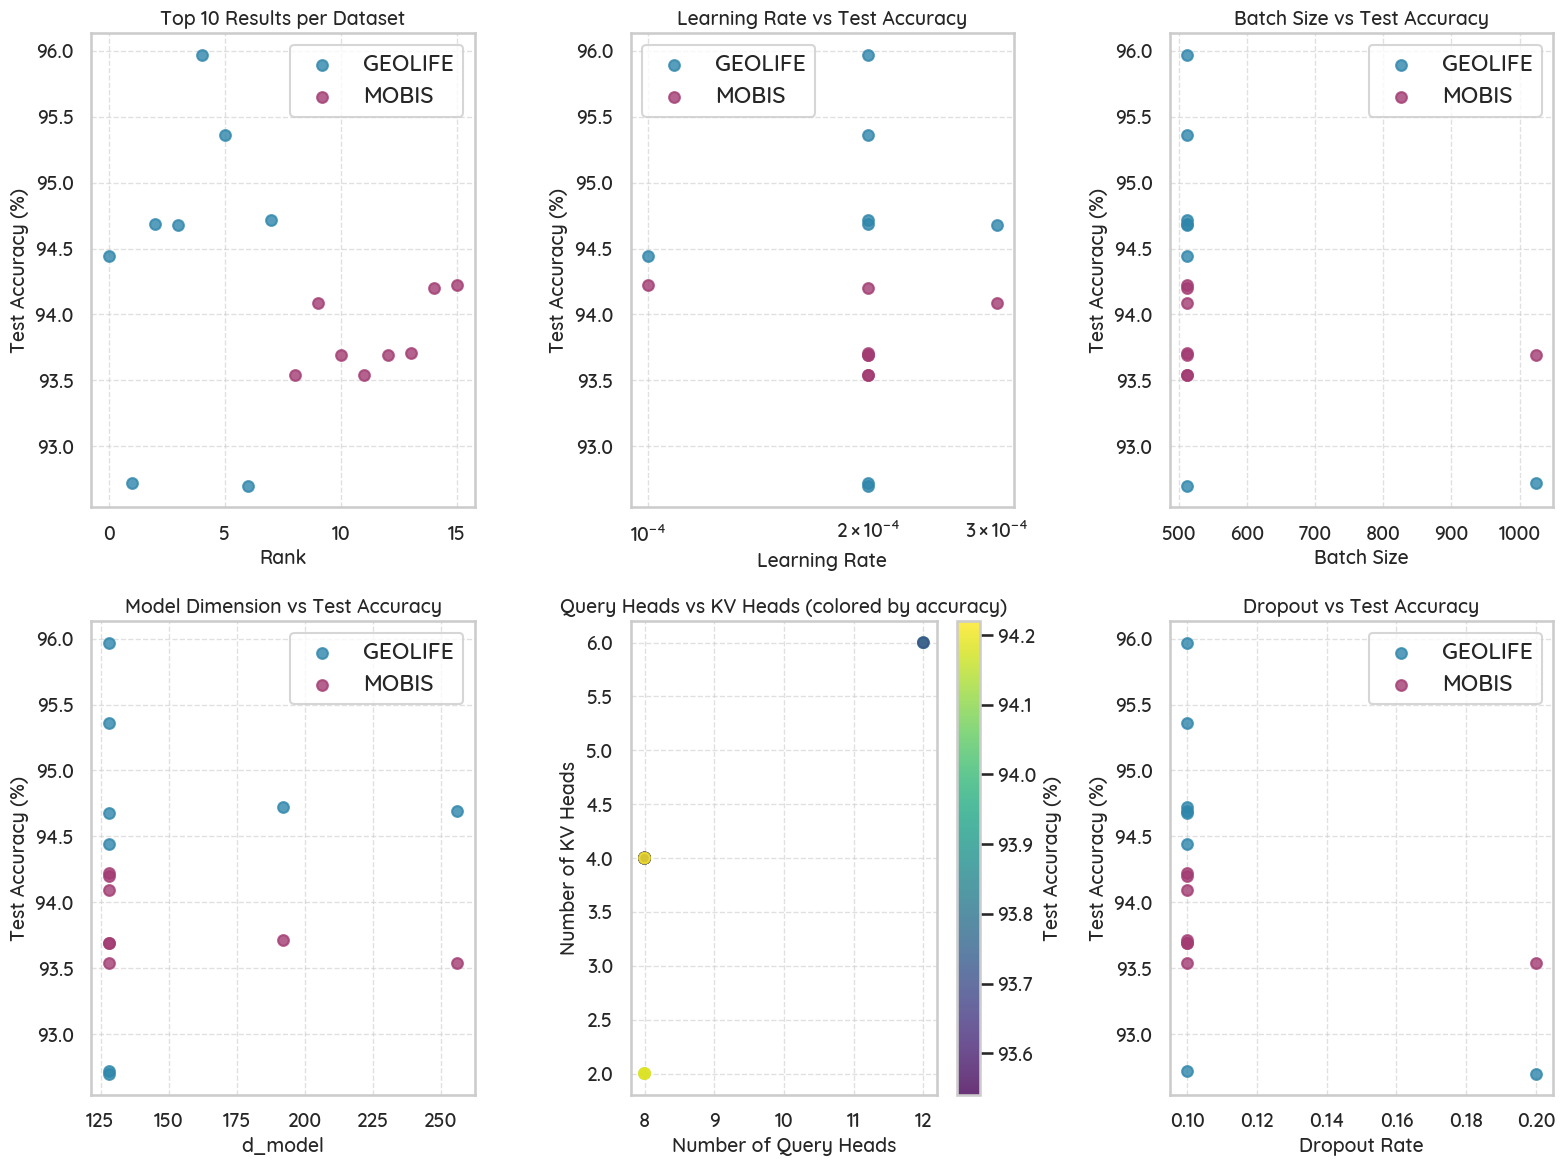


=== Statistical Summary by Dataset ===


,mean,std,min,max,count
dataset,,,,,
geolife,94.41,1.16,92.70,95.97,8
mobis,93.84,0.29,93.54,94.22,8


In [17]:
# Create comprehensive visualizations with consistent theme
if not df_enhanced.empty:
    # Define colors for datasets
    dataset_colors = {
        'geolife': color_accent,
        'mobis': color_highlight
    }
    
    # 1. Comparison of best results between datasets
    plt.figure(figsize=(16, 12))
    
    # Top 10 results per dataset
    plt.subplot(2, 3, 1)
    for dataset in df_enhanced['dataset'].unique():
        df_subset = df_enhanced[df_enhanced['dataset'] == dataset].sort_values('test_acc', ascending=False).head(10)
        plt.scatter(df_subset.index, df_subset['test_acc'], 
                   label=f'{dataset.upper()}', s=60, alpha=0.8, color=dataset_colors.get(dataset, color_primary))
    
    plt.title('Top 10 Results per Dataset')
    plt.xlabel('Rank')
    plt.ylabel('Test Accuracy (%)')
    plt.legend()
    plt.grid(True, alpha=0.6, linestyle='--')
    
    # 2. Learning Rate vs Accuracy
    plt.subplot(2, 3, 2)
    for dataset in df_enhanced['dataset'].unique():
        df_subset = df_enhanced[df_enhanced['dataset'] == dataset]
        plt.scatter(df_subset['learning_rate'], df_subset['test_acc'], 
                   label=f'{dataset.upper()}', s=60, alpha=0.8, color=dataset_colors.get(dataset, color_primary))
    
    plt.title('Learning Rate vs Test Accuracy')
    plt.xlabel('Learning Rate')
    plt.ylabel('Test Accuracy (%)')
    plt.xscale('log')
    plt.legend()
    plt.grid(True, alpha=0.6, linestyle='--')
    
    # 3. Batch Size vs Accuracy
    plt.subplot(2, 3, 3)
    for dataset in df_enhanced['dataset'].unique():
        df_subset = df_enhanced[df_enhanced['dataset'] == dataset]
        if 'batch_size' in df_subset.columns:
            plt.scatter(df_subset['batch_size'], df_subset['test_acc'], 
                       label=f'{dataset.upper()}', s=60, alpha=0.8, color=dataset_colors.get(dataset, color_primary))
    
    plt.title('Batch Size vs Test Accuracy')
    plt.xlabel('Batch Size')
    plt.ylabel('Test Accuracy (%)')
    plt.legend()
    plt.grid(True, alpha=0.6, linestyle='--')
    
    # 4. d_model vs Accuracy
    plt.subplot(2, 3, 4)
    for dataset in df_enhanced['dataset'].unique():
        df_subset = df_enhanced[df_enhanced['dataset'] == dataset]
        if 'd_model' in df_subset.columns:
            plt.scatter(df_subset['d_model'], df_subset['test_acc'], 
                       label=f'{dataset.upper()}', s=60, alpha=0.8, color=dataset_colors.get(dataset, color_primary))
    
    plt.title('Model Dimension vs Test Accuracy')
    plt.xlabel('d_model')
    plt.ylabel('Test Accuracy (%)')
    plt.legend()
    plt.grid(True, alpha=0.6, linestyle='--')
    
    # 5. Number of Heads vs KV Heads (GQA Analysis)
    plt.subplot(2, 3, 5)
    for dataset in df_enhanced['dataset'].unique():
        df_subset = df_enhanced[df_enhanced['dataset'] == dataset]
        if 'n_heads' in df_subset.columns and 'kv_heads' in df_subset.columns:
            scatter = plt.scatter(df_subset['n_heads'], df_subset['kv_heads'], 
                                c=df_subset['test_acc'], s=60, alpha=0.8, cmap='viridis')
    
    plt.title('Query Heads vs KV Heads (colored by accuracy)')
    plt.xlabel('Number of Query Heads')
    plt.ylabel('Number of KV Heads')
    if 'test_acc' in df_enhanced.columns:
        plt.colorbar(scatter, label='Test Accuracy (%)')
    plt.grid(True, alpha=0.6, linestyle='--')
    
    # 6. Dropout vs Accuracy
    plt.subplot(2, 3, 6)
    for dataset in df_enhanced['dataset'].unique():
        df_subset = df_enhanced[df_enhanced['dataset'] == dataset]
        if 'dropout' in df_subset.columns:
            plt.scatter(df_subset['dropout'], df_subset['test_acc'], 
                       label=f'{dataset.upper()}', s=60, alpha=0.8, color=dataset_colors.get(dataset, color_primary))
    
    plt.title('Dropout vs Test Accuracy')
    plt.xlabel('Dropout Rate')
    plt.ylabel('Test Accuracy (%)')
    plt.legend()
    plt.grid(True, alpha=0.6, linestyle='--')
    
    plt.tight_layout()
    plt.show()
    
    # Statistical summary by dataset
    print("\n=== Statistical Summary by Dataset ===")
    summary_stats = df_enhanced.groupby('dataset')['test_acc'].agg(['mean', 'std', 'min', 'max', 'count']).round(2)
    display(summary_stats)
else:
    print("No data available for visualization")


=== BEST CONFIGURATIONS ===

GEOLIFE Dataset:
  Test Accuracy: 95.970%
  Test Loss: 0.1525
  Hyperparameters:
    - Learning Rate: 0.0002
    - Batch Size: 512
    - Query Heads: 8
    - KV Heads: 4
    - GQA Compression Ratio: 2.0:1
    - Model Dimension: 128
    - Dropout: 0.1
  Run Name: lr2e-4_bs512_h8_d128_kv4_do0.1

MOBIS Dataset:
  Test Accuracy: 94.220%
  Test Loss: 0.1627
  Hyperparameters:
    - Learning Rate: 0.0001
    - Batch Size: 512
    - Query Heads: 8
    - KV Heads: 4
    - GQA Compression Ratio: 2.0:1
    - Model Dimension: 128
    - Dropout: 0.1
  Run Name: mobis_lr1e-4_bs512_h8_d128_kv4_do0.1

=== GROUP QUERY ATTENTION (GQA) ANALYSIS ===
Performance by GQA Compression Ratio:


,mean,std,count
gqa_ratio,,,
4.0,94.780,0.82,2
2.0,94.029,0.86,14


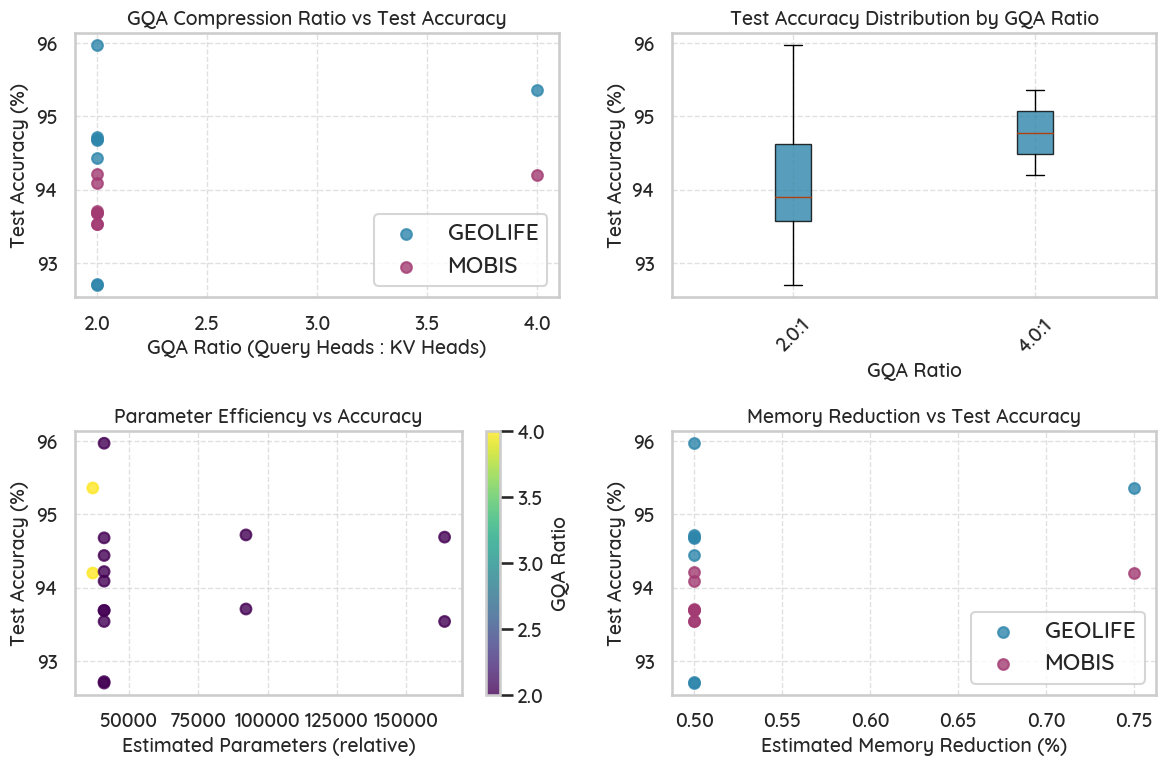


=== TOP 5 HYPERPARAMETER COMBINATIONS ===

#1 - GEOLIFE - 95.970%
   Run: lr2e-4_bs512_h8_d128_kv4_do0.1
   LR: 0.0002, BS: 512, Heads: 8, KV: 4, D: 128, DO: 0.1

#2 - GEOLIFE - 95.360%
   Run: lr2e-4_bs512_h8_d128_kv2_do0.1
   LR: 0.0002, BS: 512, Heads: 8, KV: 2, D: 128, DO: 0.1

#3 - GEOLIFE - 94.720%
   Run: lr2e-4_bs512_h12_d192_kv6_do0.1
   LR: 0.0002, BS: 512, Heads: 12, KV: 6, D: 192, DO: 0.1

#4 - GEOLIFE - 94.690%
   Run: lr2e-4_bs512_h8_d256_kv4_do0.1
   LR: 0.0002, BS: 512, Heads: 8, KV: 4, D: 256, DO: 0.1

#5 - GEOLIFE - 94.680%
   Run: lr3e-4_bs512_h8_d128_kv4_do0.1
   LR: 0.0003, BS: 512, Heads: 8, KV: 4, D: 128, DO: 0.1


In [18]:
# Detailed analysis of best configurations and GQA impact with consistent theme
if not df_enhanced.empty:
    # Print best configurations for each dataset
    print("\n=== BEST CONFIGURATIONS ===")
    for dataset in df_enhanced['dataset'].unique():
        best_run = df_enhanced[df_enhanced['dataset'] == dataset].sort_values('test_acc', ascending=False).iloc[0]
        print(f"\n{dataset.upper()} Dataset:")
        print(f"  Test Accuracy: {best_run['test_acc']:.3f}%")
        print(f"  Test Loss: {best_run['test_loss']:.4f}")
        print(f"  Hyperparameters:")
        
        if 'learning_rate' in best_run:
            print(f"    - Learning Rate: {best_run['learning_rate']}")
        if 'batch_size' in best_run:
            print(f"    - Batch Size: {best_run['batch_size']}")
        if 'n_heads' in best_run:
            print(f"    - Query Heads: {best_run['n_heads']}")
        if 'kv_heads' in best_run:
            print(f"    - KV Heads: {best_run['kv_heads']}")
            if 'n_heads' in best_run:
                compression_ratio = best_run['n_heads'] / best_run['kv_heads']
                print(f"    - GQA Compression Ratio: {compression_ratio:.1f}:1")
        if 'd_model' in best_run:
            print(f"    - Model Dimension: {best_run['d_model']}")
        if 'num_layers' in best_run:
            print(f"    - Number of Layers: {best_run['num_layers']}")
        if 'dropout' in best_run:
            print(f"    - Dropout: {best_run['dropout']}")
        
        print(f"  Run Name: {best_run['run_name']}")
    
    # Analysis of Group Query Attention (GQA) impact
    if 'n_heads' in df_enhanced.columns and 'kv_heads' in df_enhanced.columns:
        df_enhanced['gqa_ratio'] = df_enhanced['n_heads'] / df_enhanced['kv_heads']
        
        print("\n=== GROUP QUERY ATTENTION (GQA) ANALYSIS ===")
        gqa_analysis = df_enhanced.groupby('gqa_ratio')['test_acc'].agg(['mean', 'std', 'count']).round(3)
        gqa_analysis = gqa_analysis.sort_values('mean', ascending=False)
        print("Performance by GQA Compression Ratio:")
        display(gqa_analysis)
        
        # Visualize GQA impact with consistent theme
        dataset_colors = {'geolife': color_accent, 'mobis': color_highlight}
        
        plt.figure(figsize=(12, 8))
        
        plt.subplot(2, 2, 1)
        for dataset in df_enhanced['dataset'].unique():
            df_subset = df_enhanced[df_enhanced['dataset'] == dataset]
            plt.scatter(df_subset['gqa_ratio'], df_subset['test_acc'], 
                       label=f'{dataset.upper()}', s=60, alpha=0.8, 
                       color=dataset_colors.get(dataset, color_primary))
        
        plt.title('GQA Compression Ratio vs Test Accuracy')
        plt.xlabel('GQA Ratio (Query Heads : KV Heads)')
        plt.ylabel('Test Accuracy (%)')
        plt.legend()
        plt.grid(True, alpha=0.6, linestyle='--')
        
        # Box plot of GQA ratios
        plt.subplot(2, 2, 2)
        unique_ratios = sorted(df_enhanced['gqa_ratio'].unique())
        gqa_data = [df_enhanced[df_enhanced['gqa_ratio'] == ratio]['test_acc'].values 
                   for ratio in unique_ratios]
        
        box_plot = plt.boxplot(gqa_data, labels=[f'{r:.1f}:1' for r in unique_ratios], 
                              patch_artist=True)
        for patch in box_plot['boxes']:
            patch.set_facecolor(color_accent)
            patch.set_alpha(0.8)
        
        plt.title('Test Accuracy Distribution by GQA Ratio')
        plt.xlabel('GQA Ratio')
        plt.ylabel('Test Accuracy (%)')
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.6, linestyle='--')
        
        # Parameter efficiency analysis
        if 'd_model' in df_enhanced.columns:
            plt.subplot(2, 2, 3)
            df_enhanced['kv_params_ratio'] = df_enhanced['kv_heads'] / df_enhanced['n_heads']
            df_enhanced['estimated_params'] = (df_enhanced['d_model'] ** 2) * (2 + df_enhanced['kv_params_ratio'])
            
            plt.scatter(df_enhanced['estimated_params'], df_enhanced['test_acc'], 
                       c=df_enhanced['gqa_ratio'], s=60, alpha=0.8, cmap='viridis')
            plt.title('Parameter Efficiency vs Accuracy')
            plt.xlabel('Estimated Parameters (relative)')
            plt.ylabel('Test Accuracy (%)')
            plt.colorbar(label='GQA Ratio')
            plt.grid(True, alpha=0.6, linestyle='--')
        
        # Performance vs compression trade-off
        plt.subplot(2, 2, 4)
        for dataset in df_enhanced['dataset'].unique():
            df_subset = df_enhanced[df_enhanced['dataset'] == dataset]
            df_subset_copy = df_subset.copy()
            df_subset_copy['memory_reduction'] = 1 - (1/df_subset_copy['gqa_ratio'])
            
            plt.scatter(df_subset_copy['memory_reduction'], df_subset_copy['test_acc'], 
                       label=f'{dataset.upper()}', s=60, alpha=0.8,
                       color=dataset_colors.get(dataset, color_primary))
        
        plt.title('Memory Reduction vs Test Accuracy')
        plt.xlabel('Estimated Memory Reduction (%)')
        plt.ylabel('Test Accuracy (%)')
        plt.legend()
        plt.grid(True, alpha=0.6, linestyle='--')
        
        plt.tight_layout()
        plt.show()
    
    # Top performing hyperparameter combinations
    print("\n=== TOP 5 HYPERPARAMETER COMBINATIONS ===")
    top_configs = df_enhanced.nlargest(5, 'test_acc')
    for i, (_, config) in enumerate(top_configs.iterrows(), 1):
        print(f"\n#{i} - {config['dataset'].upper()} - {config['test_acc']:.3f}%")
        print(f"   Run: {config['run_name']}")
        if 'learning_rate' in config:
            print(f"   LR: {config['learning_rate']}, ", end="")
        if 'batch_size' in config:
            print(f"BS: {config['batch_size']}, ", end="")
        if 'n_heads' in config:
            print(f"Heads: {config['n_heads']}, ", end="")
        if 'kv_heads' in config:
            print(f"KV: {config['kv_heads']}, ", end="")
        if 'd_model' in config:
            print(f"D: {config['d_model']}, ", end="")
        if 'dropout' in config:
            print(f"DO: {config['dropout']}")
        else:
            print()
else:
    print("No enhanced transformer data available for detailed analysis")

# Miniprogram Subset Sweep Results

Visualization of SpeedTransformer performance on different miniprogram data subset sizes after hyperparameter tuning.

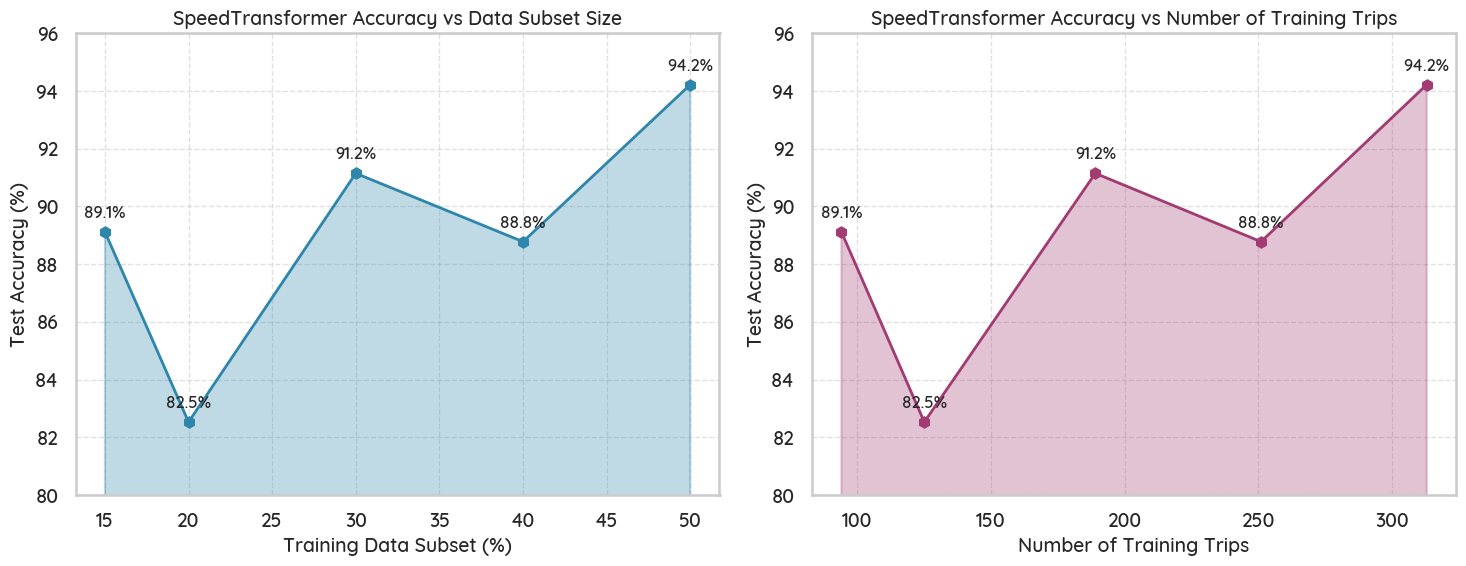

=== Miniprogram Subset Sweep Summary ===
Best Performance: 94.22% with 313 training trips (50%)
Worst Performance: 82.53% with 125 training trips (20%)
Performance Range: 11.69 percentage points
Mean Accuracy: 89.16% ± 3.84%

=== Data Efficiency Analysis ===
15% ( 94 trips): 89.12% accuracy, 0.9481 acc/trip
20% (125 trips): 82.53% accuracy, 0.6602 acc/trip
30% (189 trips): 91.15% accuracy, 0.4823 acc/trip
40% (251 trips): 88.78% accuracy, 0.3537 acc/trip
50% (313 trips): 94.22% accuracy, 0.3010 acc/trip


In [19]:
# Miniprogram subset sweep results with consistent theme
# Data from the sweep results
subset_percentages = [15, 20, 30, 40, 50]
num_trips = [94, 125, 189, 251, 313]
accuracies = [89.12, 82.53, 91.15, 88.78, 94.22]

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Accuracy vs Subset Percentage
ax1.plot(subset_percentages, accuracies, 'h-', linewidth=2, markersize=8, color=color_accent)
ax1.fill_between(subset_percentages, accuracies, alpha=0.3, color=color_accent)

# Add value labels on points
for x, y in zip(subset_percentages, accuracies):
    ax1.annotate(f'{y:.1f}%', (x, y), textcoords="offset points", 
                xytext=(0, 10), ha='center', fontsize=12, fontweight='bold')

ax1.set_title('SpeedTransformer Accuracy vs Data Subset Size')
ax1.set_xlabel('Training Data Subset (%)')
ax1.set_ylabel('Test Accuracy (%)')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.set_ylim(80, 96)

# Plot 2: Accuracy vs Number of Training Trips
ax2.plot(num_trips, accuracies, 'h-', linewidth=2, markersize=8, color=color_highlight)
ax2.fill_between(num_trips, accuracies, alpha=0.3, color=color_highlight)

# Add value labels on points
for x, y in zip(num_trips, accuracies):
    ax2.annotate(f'{y:.1f}%', (x, y), textcoords="offset points", 
                xytext=(0, 10), ha='center', fontsize=12, fontweight='bold')

ax2.set_title('SpeedTransformer Accuracy vs Number of Training Trips')
ax2.set_xlabel('Number of Training Trips')
ax2.set_ylabel('Test Accuracy (%)')
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.set_ylim(80, 96)

plt.tight_layout()
plt.show()

# Print summary statistics
print("=== Miniprogram Subset Sweep Summary ===")
print(f"Best Performance: {max(accuracies):.2f}% with {num_trips[accuracies.index(max(accuracies))]} training trips ({subset_percentages[accuracies.index(max(accuracies))]}%)")
print(f"Worst Performance: {min(accuracies):.2f}% with {num_trips[accuracies.index(min(accuracies))]} training trips ({subset_percentages[accuracies.index(min(accuracies))]}%)")
print(f"Performance Range: {max(accuracies) - min(accuracies):.2f} percentage points")
print(f"Mean Accuracy: {np.mean(accuracies):.2f}% ± {np.std(accuracies):.2f}%")

# Performance vs data size analysis
print("\n=== Data Efficiency Analysis ===")
for i, (pct, trips, acc) in enumerate(zip(subset_percentages, num_trips, accuracies)):
    efficiency = acc / trips  # accuracy per training trip
    print(f"{pct:2d}% ({trips:3d} trips): {acc:5.2f}% accuracy, {efficiency:.4f} acc/trip")